Dataset Shape: (9994, 26)

Columns:
Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Profit_Margin', 'Shipping_Days', 'Is_Loss', 'Order_Year',
       'Order_Month'],
      dtype='object')


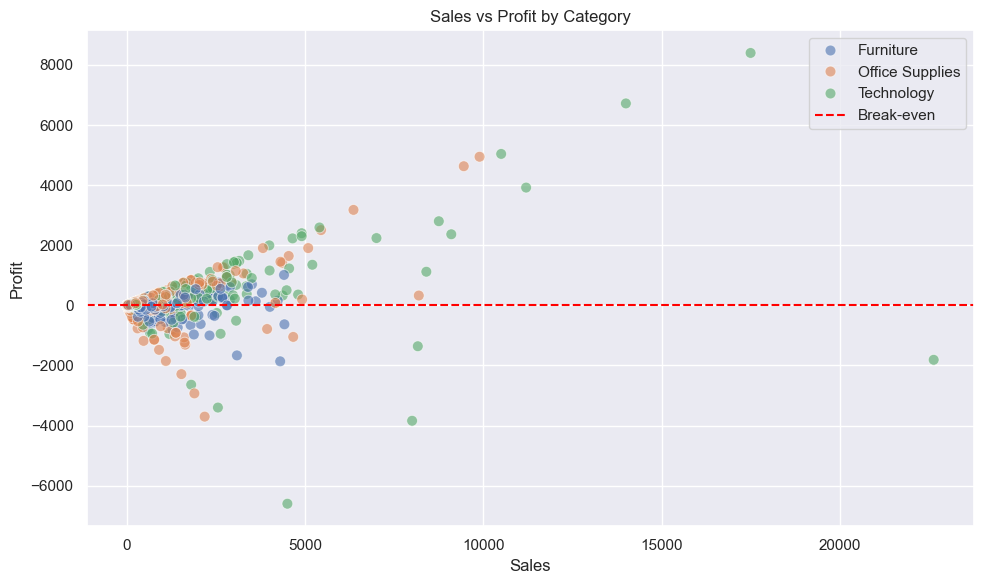

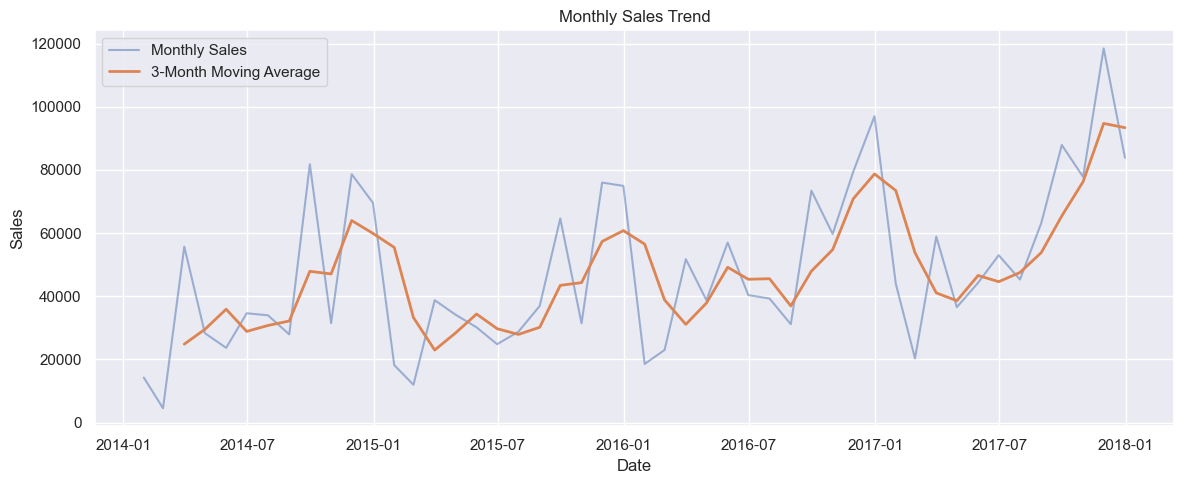

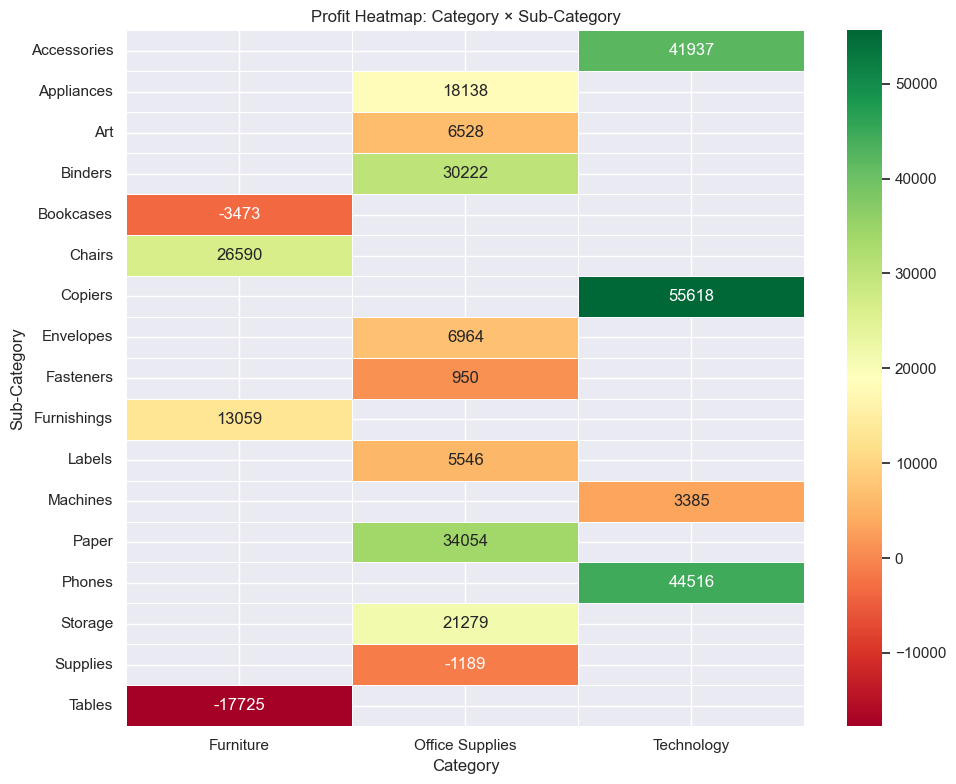

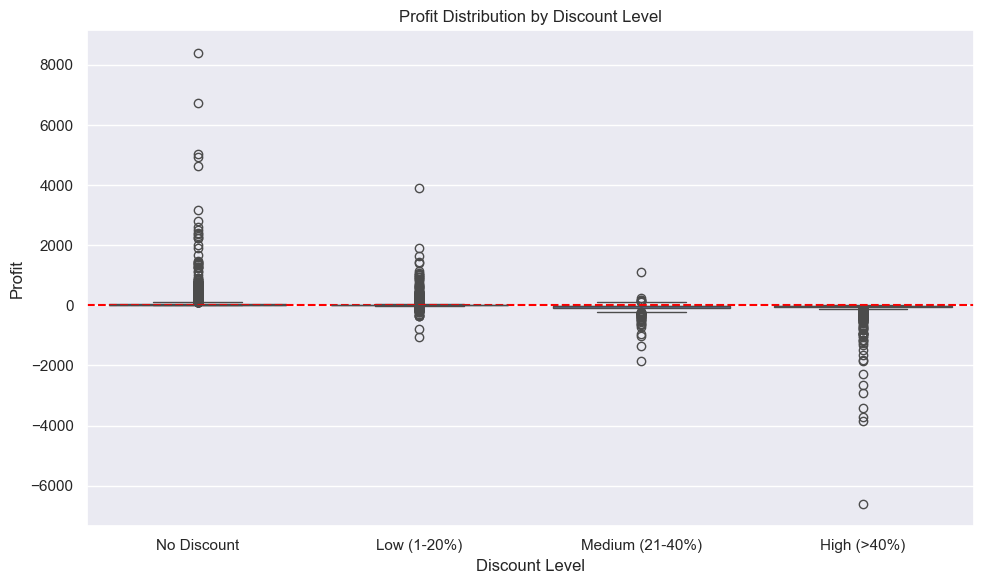

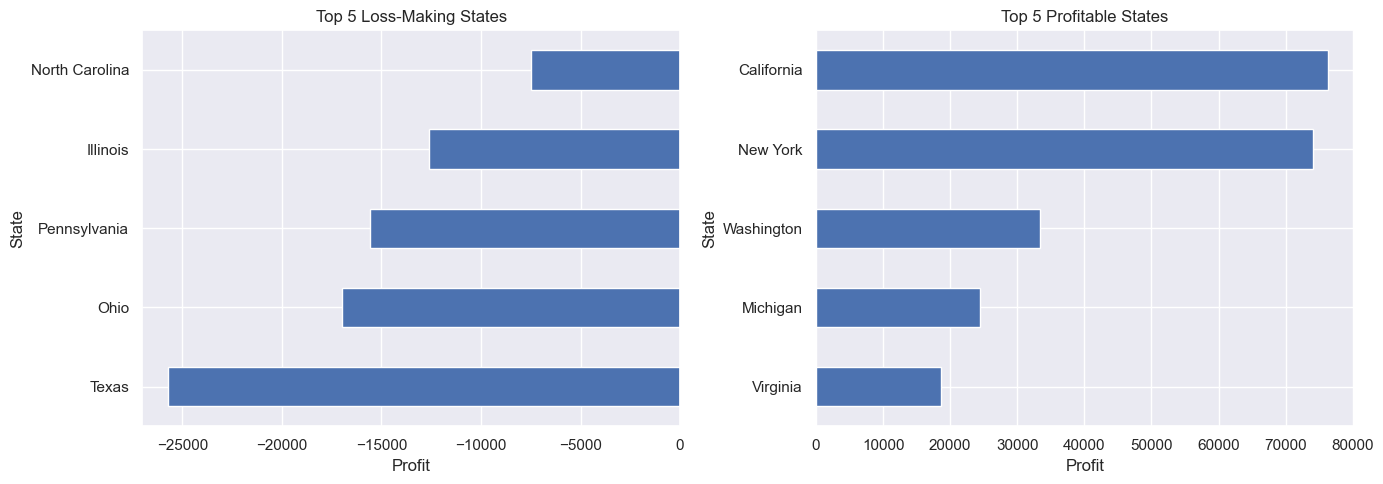

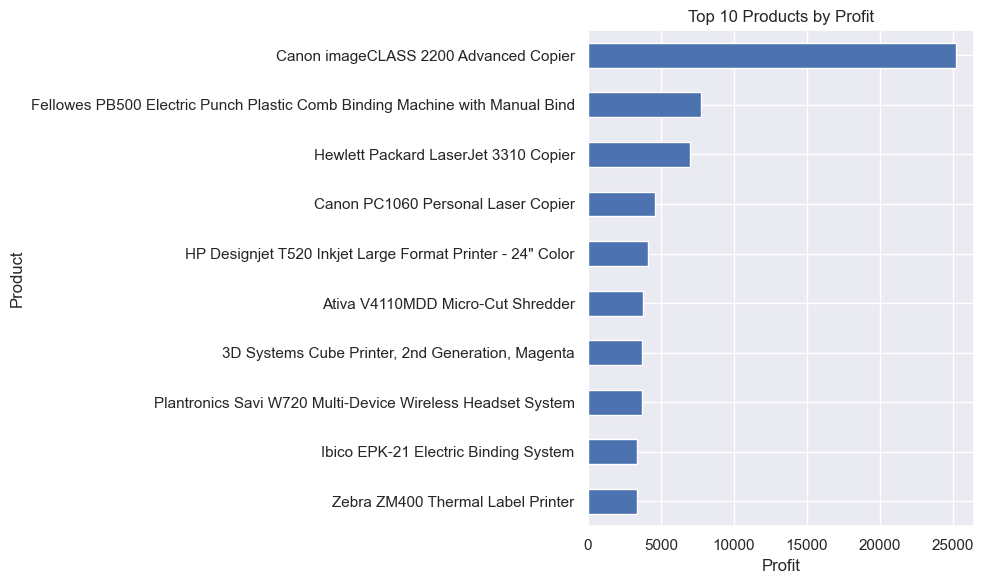


Regional Performance
               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625

Category Performance
                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Office Supplies  719047.0320  122490.8008
Furniture        741999.7953   18451.2728

========== BUSINESS KPIs ==========
Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Average Profit Margin: 12.03


In [5]:
# ==========================================
# Superstore Sales Analysis Project
# Author: Sanjana
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ------------------------------------------
# Load Libraries & Dataset
# ------------------------------------------

sns.set_theme(style='darkgrid', palette='deep')

df = pd.read_csv('superstore_clean.csv')

# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# ==========================================
# 1. Sales vs Profit Analysis
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    alpha=0.6,
    s=60
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    label='Break-even'
)

plt.title('Sales vs Profit by Category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 2. Monthly Sales Trend
# ==========================================

monthly = (
    df.resample('M', on='Order_Date')['Sales']
      .sum()
      .reset_index()
)

monthly['Rolling_Avg'] = (
    monthly['Sales']
    .rolling(3)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly['Order_Date'],
    monthly['Sales'],
    label='Monthly Sales',
    alpha=0.5
)

plt.plot(
    monthly['Order_Date'],
    monthly['Rolling_Avg'],
    linewidth=2,
    label='3-Month Moving Average'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 3. Profit Heatmap
# Category vs Sub-Category
# ==========================================

pivot = df.pivot_table(
    values='Profit',
    index='Sub-Category',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title('Profit Heatmap: Category × Sub-Category')
plt.tight_layout()
plt.show()

# ==========================================
# 4. Discount Impact Analysis
# ==========================================

df['Discount_Level'] = pd.cut(
    df['Discount'],
    bins=[-1, 0, 0.2, 0.4, 1],
    labels=[
        'No Discount',
        'Low (1-20%)',
        'Medium (21-40%)',
        'High (>40%)'
    ]
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Discount_Level',
    y='Profit'
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title('Profit Distribution by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

# ==========================================
# 5. Top & Bottom States by Profit
# ==========================================

state_profit = (
    df.groupby('State')['Profit']
      .sum()
      .sort_values()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Bottom 5 States

state_profit.head(5).plot(
    kind='barh',
    ax=axes[0]
)

axes[0].set_title('Top 5 Loss-Making States')
axes[0].set_xlabel('Profit')

# Top 5 States

state_profit.tail(5).plot(
    kind='barh',
    ax=axes[1]
)

axes[1].set_title('Top 5 Profitable States')
axes[1].set_xlabel('Profit')

plt.tight_layout()
plt.show()

# ==========================================
# 6. Top 10 Products by Profit
# ==========================================

top_products = (
    df.groupby('Product_Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

# ==========================================
# 7. Regional Performance
# ==========================================

regional = (
    df.groupby('Region')[['Sales', 'Profit']]
      .sum()
      .sort_values('Profit', ascending=False)
)

print("\nRegional Performance")
print(regional)

# ==========================================
# 8. Category Performance
# ==========================================

category_perf = (
    df.groupby('Category')[['Sales', 'Profit']]
      .sum()
      .sort_values('Profit', ascending=False)
)

print("\nCategory Performance")
print(category_perf)

# ==========================================
# 9. Key Business Metrics
# ==========================================

print("\n========== BUSINESS KPIs ==========")

print("Total Sales:",
      round(df['Sales'].sum(), 2))

print("Total Profit:",
      round(df['Profit'].sum(), 2))

print("Total Orders:",
      df['Order_ID'].nunique())

print("Total Customers:",
      df['Customer_ID'].nunique())

print("Average Profit Margin:",
      round(df['Profit_Margin'].mean(), 2))

print("===================================")

In [ ]:
## 📌 Key Insights Found

1. Technology is the most profitable category (avg margin 17%).
2. Furniture loses money despite being 2nd highest in sales.
3. Discounts above 40% result in NEGATIVE average profit.
4. California generates highest revenue but Texas has highest losses.
5. Same-Day shipping has lowest order count but highest avg profit margin.